In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

C:\Users\alext\miniconda3\envs\ecomms-ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
customers = pd.read_csv("../data/cleaned_data/customers.csv", encoding='latin-1')
order_items = pd.read_csv("../data/cleaned_data/order_items.csv")
orders = pd.read_csv("../data/cleaned_data/orders_cleaned.csv")

C:\Users\alext\AppData\Local\Temp\ipykernel_12328\2509920600.py:1: DtypeWarning: Columns (0: zip) have mixed types. Specify dtype option on import or set low_memory=False.
  customers = pd.read_csv("../data/cleaned_data/customers.csv", encoding='latin-1')


In [3]:
orders["orderId"] = orders["orderId"].astype(str)
orders['createdAt'] = pd.to_datetime(orders['createdAt'])
orders['processedAt'] = pd.to_datetime(orders['processedAt'])
orders['closedAt'] = pd.to_datetime(orders['closedAt'])

In [4]:
order_items["orderId"] = order_items["orderId"].astype(str)
order_items["orderItemId"] = order_items["orderItemId"].astype(str)

In [5]:
order_items = order_items.merge(
    orders[["orderId", "createdAt"]],
    on="orderId",
    how="left"
)

In [6]:
order_items = order_items[~(
    (order_items["createdAt"].dt.year == 2022) &
    (order_items["createdAt"].dt.month == 5)
)]

In [7]:
daily_revenue = (
    order_items
    .groupby("createdAt")
    .agg(revenue=("totalUnitPrice", "sum"))
    .reset_index()
)

In [8]:
daily_revenue = daily_revenue.rename(
    columns={
        "createdAt": "ds",
        "revenue": "y"
    }
)

In [9]:
daily_revenue.describe()

,ds,y
count,1346,1346.000000
mean,2024-04-03 12:00:00,56216.369294
min,2022-06-01 00:00:00,1766.600000
25%,2023-05-03 06:00:00,24267.525000
50%,2024-04-03 12:00:00,42427.715000
75%,2025-03-05 18:00:00,80469.652500
max,2026-02-05 00:00:00,619777.980000
std,NaN,48451.789699


<Axes: xlabel='ds'>

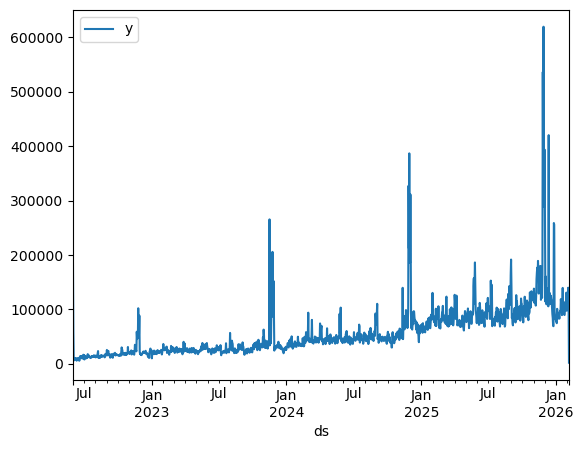

In [10]:
daily_revenue.plot(x="ds", y="y")

In [11]:
m = Prophet()
m.fit(daily_revenue)

15:13:33 - cmdstanpy - INFO - Chain [1] start processing
15:13:33 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = m.make_future_dataframe(periods=365)

In [13]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1706,2027-02-01,180644.814591,139863.092312,217040.461979
1707,2027-02-02,178771.390564,142513.971668,217389.750304
1708,2027-02-03,181596.946885,143330.897379,217389.786473
1709,2027-02-04,181578.593592,144214.346717,220065.891085
1710,2027-02-05,184802.952068,147653.484356,224844.893732


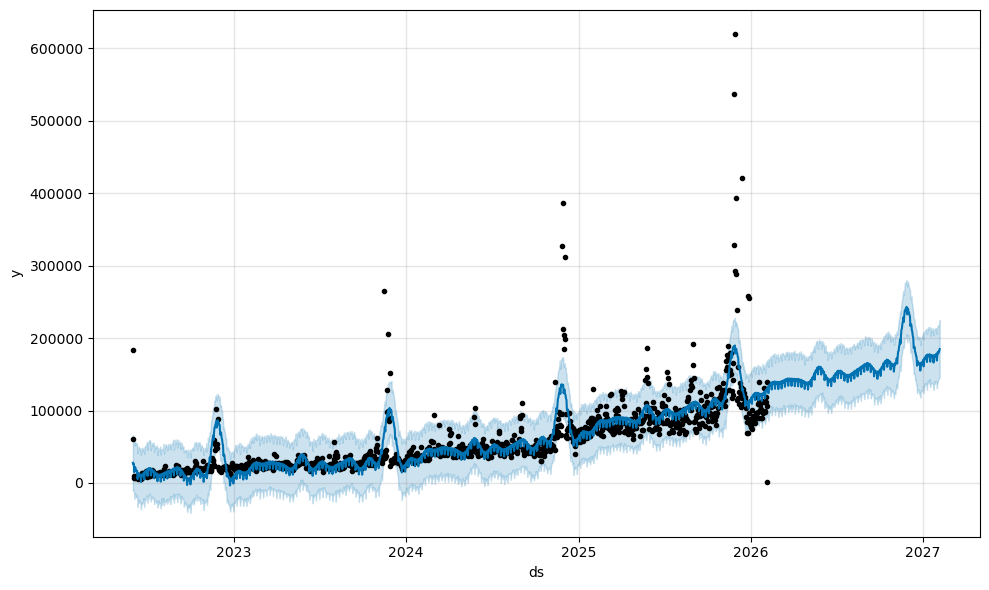

In [14]:
fig1 = m.plot(forecast)

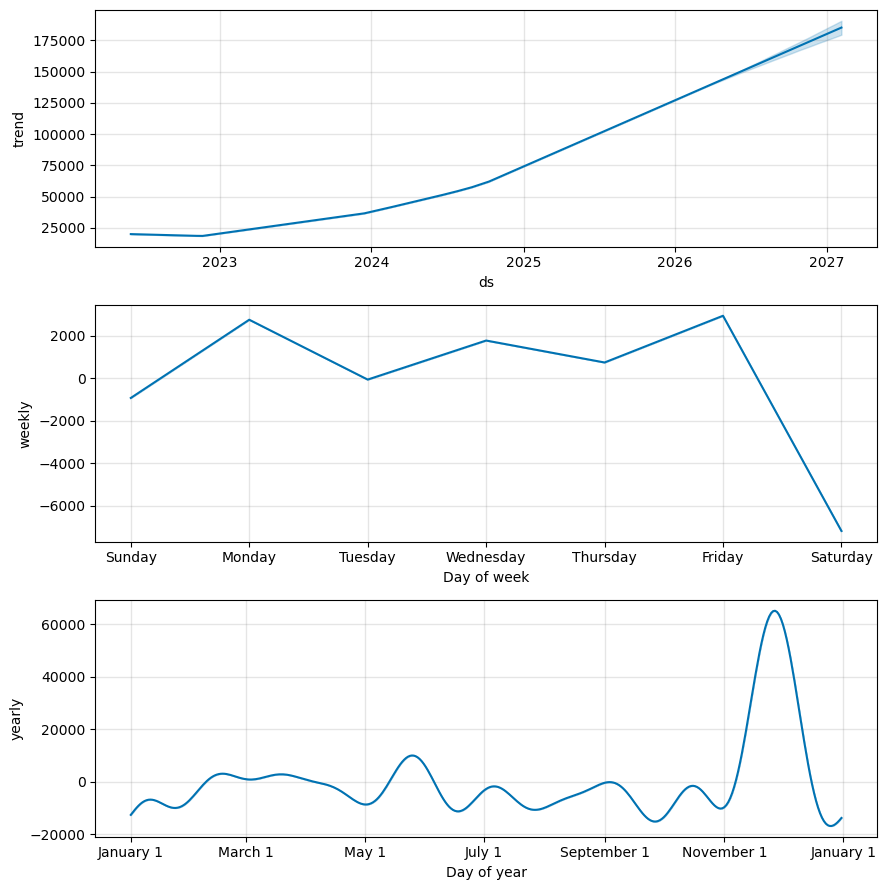

In [15]:
fig2 = m.plot_components(forecast)

Text(0.5, 1.0, 'Forecast Residuals')

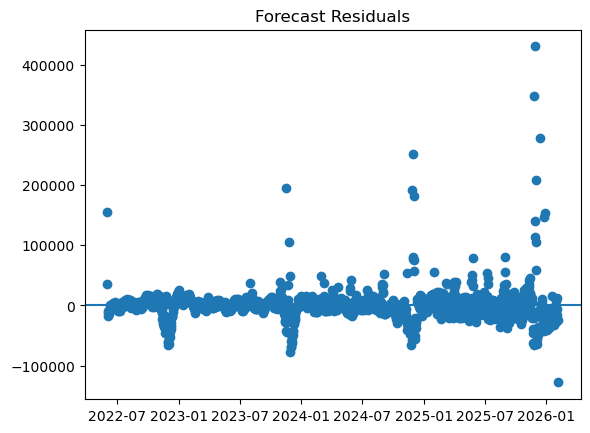

In [16]:
forecast["residual"] = daily_revenue["y"].values - forecast["yhat"][:len(daily_revenue)]

plt.scatter(forecast["ds"][:len(daily_revenue)], forecast["residual"][:len(daily_revenue)])
plt.axhline(0)
plt.title("Forecast Residuals")

Text(0.5, 1.0, 'Actual vs Predicted')

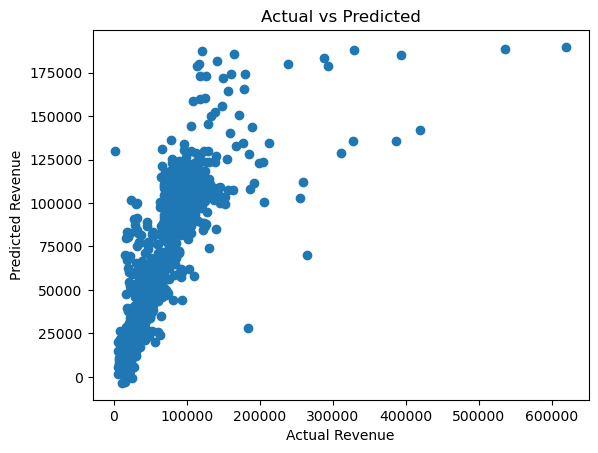

In [17]:
plt.scatter(daily_revenue["y"], forecast["yhat"][:len(daily_revenue)])
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted")

In [18]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,residual
0,2022-06-01,20115.710588,-11352.933839,65856.010742,20115.710588,20115.710588,7739.340352,7739.340352,7739.340352,1770.302013,1770.302013,1770.302013,5969.038339,5969.038339,5969.038339,0.0,0.0,0.0,27855.050941,155761.179059
1,2022-06-02,20106.331618,-9012.045589,63937.181412,20106.331618,20106.331618,5510.506655,5510.506655,5510.506655,736.950044,736.950044,736.950044,4773.556611,4773.556611,4773.556611,0.0,0.0,0.0,25616.838274,34687.051726
2,2022-06-03,20096.952648,-9198.193557,62914.875236,20096.952648,20096.952648,6411.951022,6411.951022,6411.951022,2936.626155,2936.626155,2936.626155,3475.324867,3475.324867,3475.324867,0.0,0.0,0.0,26508.903670,-17494.253670
3,2022-06-04,20087.573678,-21701.573802,51470.149050,20087.573678,20087.573678,-5093.792218,-5093.792218,-5093.792218,-7193.292749,-7193.292749,-7193.292749,2099.500531,2099.500531,2099.500531,0.0,0.0,0.0,14993.781460,-8668.191460
4,2022-06-05,20078.194708,-18201.851961,55849.468249,20078.194708,20078.194708,-259.905080,-259.905080,-259.905080,-932.703186,-932.703186,-932.703186,672.798106,672.798106,672.798106,0.0,0.0,0.0,19818.289628,-13455.859628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1706,2027-02-01,184679.955688,139863.092312,217040.461979,179064.551775,190019.457268,-4035.141097,-4035.141097,-4035.141097,2749.551996,2749.551996,2749.551996,-6784.693094,-6784.693094,-6784.693094,0.0,0.0,0.0,180644.814591,NaN
1707,2027-02-02,184825.134222,142513.971668,217389.750304,179187.591624,190193.279468,-6053.743659,-6053.743659,-6053.743659,-67.434274,-67.434274,-67.434274,-5986.309385,-5986.309385,-5986.309385,0.0,0.0,0.0,178771.390564,NaN
1708,2027-02-03,184970.312757,143330.897379,217389.786473,179310.631473,190367.101669,-3373.365872,-3373.365872,-3373.365872,1770.302013,1770.302013,1770.302013,-5143.667885,-5143.667885,-5143.667885,0.0,0.0,0.0,181596.946885,NaN
1709,2027-02-04,185115.491291,144214.346717,220065.891085,179433.671322,190541.445312,-3536.897699,-3536.897699,-3536.897699,736.950044,736.950044,736.950044,-4273.847743,-4273.847743,-4273.847743,0.0,0.0,0.0,181578.593592,NaN


In [19]:
df_cv = cross_validation(m, horizon="90 days")
df_p = performance_metrics(df_cv)

print(df_p.head())

  0%|                                                                                           | 0/20 [00:00<?, ?it/s]15:13:35 - cmdstanpy - INFO - Chain [1] start processing
15:13:35 - cmdstanpy - INFO - Chain [1] done processing
  5%|████▏                                                                              | 1/20 [00:00<00:06,  2.75it/s]15:13:35 - cmdstanpy - INFO - Chain [1] start processing
15:13:36 - cmdstanpy - INFO - Chain [1] done processing
 10%|████████▎                                                                          | 2/20 [00:00<00:06,  2.77it/s]15:13:36 - cmdstanpy - INFO - Chain [1] start processing
15:13:36 - cmdstanpy - INFO - Chain [1] done processing
 15%|████████████▍                                                                      | 3/20 [00:01<00:06,  2.68it/s]15:13:36 - cmdstanpy - INFO - Chain [1] start processing
15:13:36 - cmdstanpy - INFO - Chain [1] done processing
 20%|████████████████▌                                                  

  horizon           mse          rmse           mae      mape     mdape  \
0  9 days  3.651194e+08  19108.097504  11141.877253  0.150525  0.118067   
1 10 days  3.811034e+08  19521.869153  11603.945635  0.153966  0.120003   
2 11 days  4.111209e+08  20276.116515  12289.887156  0.165139  0.125151   
3 12 days  4.271878e+08  20668.521583  12741.016195  0.176366  0.130821   
4 13 days  4.368845e+08  20901.781759  13148.851795  0.185358  0.135884   

      smape  coverage  
0  0.156219  0.850000  
1  0.161347  0.833333  
2  0.169132  0.822222  
3  0.177255  0.816667  
4  0.184253  0.811111  


In [20]:
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,9 days,3.651194e+08,19108.097504,11141.877253,0.150525,0.118067,0.156219,0.850000
1,10 days,3.811034e+08,19521.869153,11603.945635,0.153966,0.120003,0.161347,0.833333
2,11 days,4.111209e+08,20276.116515,12289.887156,0.165139,0.125151,0.169132,0.822222
3,12 days,4.271878e+08,20668.521583,12741.016195,0.176366,0.130821,0.177255,0.816667
4,13 days,4.368845e+08,20901.781759,13148.851795,0.185358,0.135884,0.184253,0.811111
...,...,...,...,...,...,...,...,...
77,86 days,6.768599e+08,26016.532147,11611.015309,0.155912,0.129183,0.157987,0.877778
78,87 days,6.635108e+08,25758.704202,11336.804166,0.154191,0.112325,0.155079,0.900000
79,88 days,9.220581e+08,30365.409884,12193.022488,0.154555,0.110500,0.157857,0.900000
80,89 days,4.331039e+08,20811.147291,10553.717125,0.151369,0.109764,0.153001,0.905556


## Given this base Prophet model, it is able to pick up that the business is able to grow rapidly. However, it misses seasonality spikes near the end of November or early December. To improve the model, I will add in a higher point scaler as well a seasonality_mode.

In [63]:
multiply_model = Prophet(seasonality_mode="multiplicative")
multiply_model.fit(daily_revenue)

15:34:43 - cmdstanpy - INFO - Chain [1] start processing
15:34:43 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
future = multiply_model.make_future_dataframe(periods=365)
forecast_mul = multiply_model.predict(future)

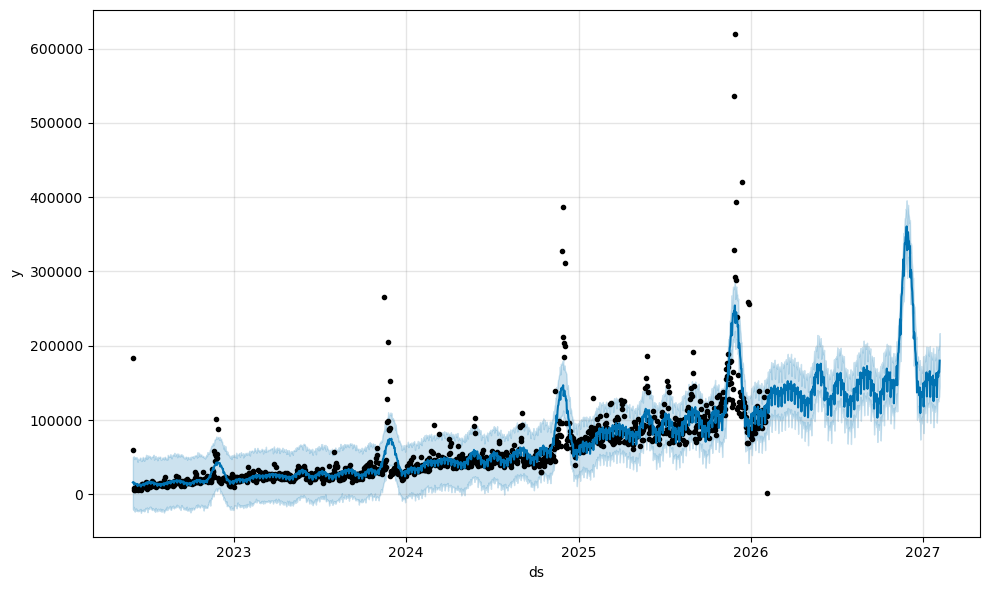

In [65]:
fig1 = multiply_model.plot(forecast_mul)

Text(0.5, 1.0, 'Forecast Residuals')

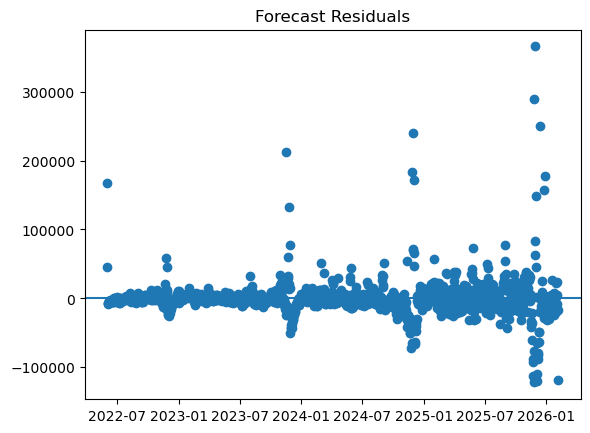

In [66]:
forecast_mul["residual"] = daily_revenue["y"].values - forecast_mul["yhat"][:len(daily_revenue)]

plt.scatter(forecast_mul["ds"][:len(daily_revenue)], forecast_mul["residual"][:len(daily_revenue)])
plt.axhline(0)
plt.title("Forecast Residuals")

Text(0.5, 1.0, 'Actual vs Predicted')

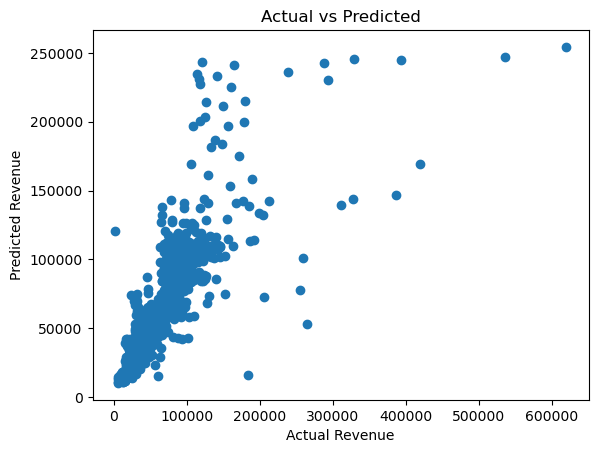

In [67]:
plt.scatter(daily_revenue["y"], forecast_mul["yhat"][:len(daily_revenue)])
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted")

In [68]:
df_cv = cross_validation(multiply_model, horizon='90 days')
df_p = performance_metrics(df_cv)

print(df_p.head())

  0%|                                                                                           | 0/20 [00:00<?, ?it/s]15:34:49 - cmdstanpy - INFO - Chain [1] start processing
15:34:49 - cmdstanpy - INFO - Chain [1] done processing
  5%|████▏                                                                              | 1/20 [00:00<00:07,  2.49it/s]15:34:50 - cmdstanpy - INFO - Chain [1] start processing
15:34:50 - cmdstanpy - INFO - Chain [1] done processing
 10%|████████▎                                                                          | 2/20 [00:00<00:06,  2.68it/s]15:34:50 - cmdstanpy - INFO - Chain [1] start processing
15:34:50 - cmdstanpy - INFO - Chain [1] done processing
 15%|████████████▍                                                                      | 3/20 [00:01<00:06,  2.82it/s]15:34:50 - cmdstanpy - INFO - Chain [1] start processing
15:34:50 - cmdstanpy - INFO - Chain [1] done processing
 20%|████████████████▌                                                  

  horizon           mse          rmse           mae      mape     mdape  \
0  9 days  3.622713e+08  19033.426261  12550.253284  0.180327  0.134876   
1 10 days  3.959212e+08  19897.768760  13251.080007  0.185223  0.140857   
2 11 days  4.411322e+08  21003.147458  14079.556214  0.202111  0.145857   
3 12 days  5.293361e+08  23007.304748  15563.559783  0.226919  0.163406   
4 13 days  5.923363e+08  24337.959145  16580.021249  0.243628  0.177309   

      smape  coverage  
0  0.178639  0.822222  
1  0.185319  0.800000  
2  0.194904  0.788889  
3  0.212879  0.761111  
4  0.225616  0.750000  


## Adding 'Multiplicative' seasonality  was tested. However, model performance decreased and MAPE increased from 15% to 18%. 

## Testing more regressors 

In [31]:
order_items_discount = order_items.merge(
    orders[["orderId", "discountCheck"]],
    on="orderId",
    how="left"
)

In [35]:
daily_revenue_discount_share = (
    order_items_discount
    .where(order_items_discount["discountCheck"] == True)
    .groupby("createdAt")
    .agg(revenue=("totalUnitPrice", "sum"))
    .reset_index()
)

In [39]:
discount_daily_revenue = daily_revenue.merge(
    daily_revenue_discount_share,
    left_on="ds",
    right_on="createdAt",
    how="left"
)

In [43]:
discount_daily_revenue = discount_daily_revenue[["ds", "y", "revenue"]].rename(
    columns={
        "ds":"ds",
        "y":"y",
        "revenue":"discount_revenue"
    }
)

In [55]:
discount_daily_revenue["discount_revenue"] = discount_daily_revenue["discount_revenue"] / discount_daily_revenue["y"]

In [69]:
discount_model = Prophet(seasonality_mode="multiplicative")
discount_model.add_regressor("discount_revenue")
discount_model.fit(discount_daily_revenue)

15:35:14 - cmdstanpy - INFO - Chain [1] start processing
15:35:14 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
future = discount_model.make_future_dataframe(periods=365)
future["discount_revenue"] = discount_daily_revenue["discount_revenue"].mean()
forecast_dis = discount_model.predict(future)

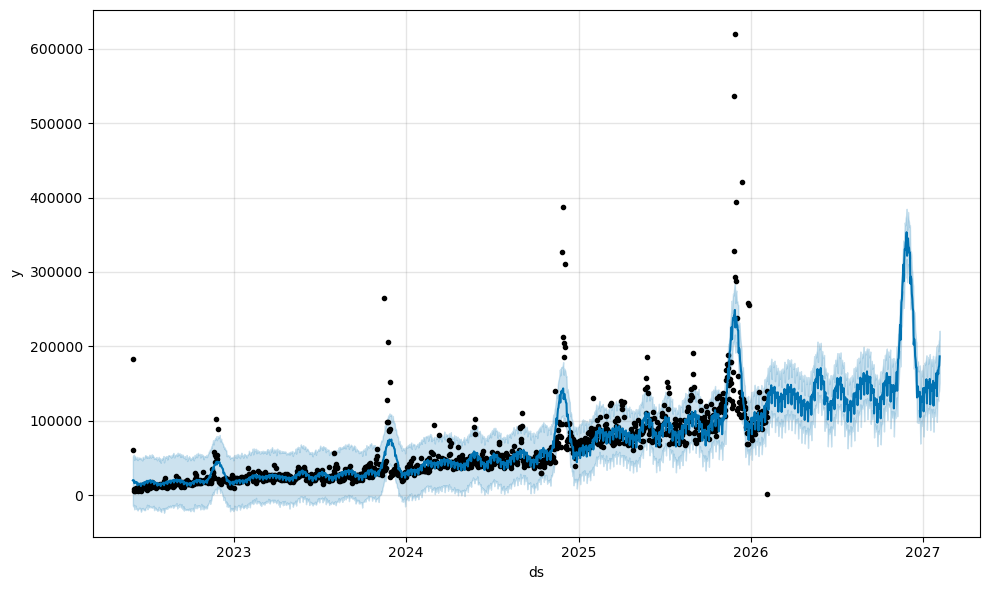

In [71]:
fig1 = discount_model.plot(forecast_dis)

Text(0.5, 1.0, 'Forecast Residuals')

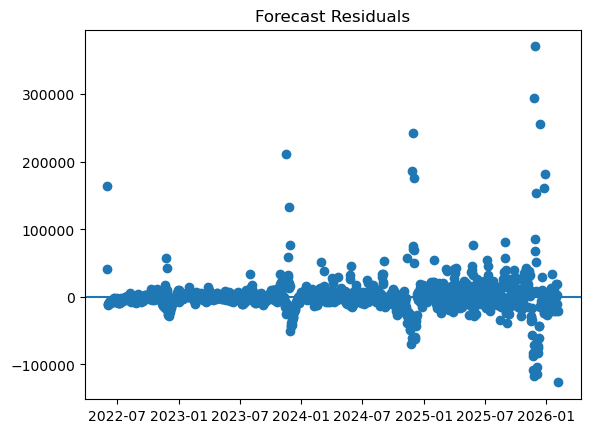

In [72]:
forecast_dis["residual"] = discount_daily_revenue["y"].values - forecast_dis["yhat"][:len(discount_daily_revenue)]

plt.scatter(forecast_dis["ds"][:len(discount_daily_revenue)], forecast_dis["residual"][:len(discount_daily_revenue)])
plt.axhline(0)
plt.title("Forecast Residuals")

Text(0.5, 1.0, 'Actual vs Predicted')

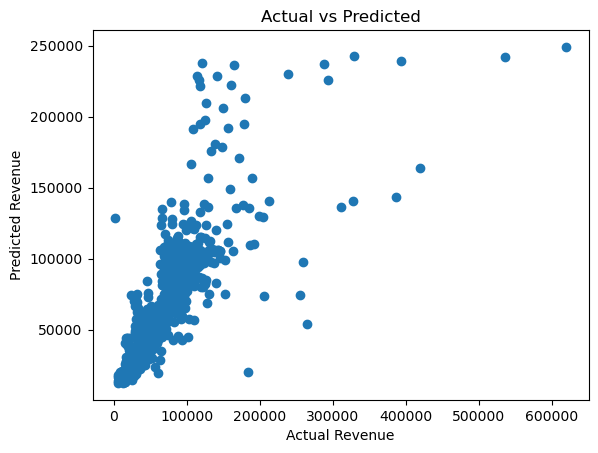

In [73]:
plt.scatter(discount_daily_revenue["y"], forecast_dis["yhat"][:len(discount_daily_revenue)])
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted")

In [74]:
df_cv = cross_validation(discount_model, horizon='90 days')
df_p = performance_metrics(df_cv)

print(df_p.head())

  0%|                                                                                           | 0/20 [00:00<?, ?it/s]15:35:30 - cmdstanpy - INFO - Chain [1] start processing
15:35:30 - cmdstanpy - INFO - Chain [1] done processing
  5%|████▏                                                                              | 1/20 [00:00<00:06,  2.97it/s]15:35:30 - cmdstanpy - INFO - Chain [1] start processing
15:35:31 - cmdstanpy - INFO - Chain [1] done processing
 10%|████████▎                                                                          | 2/20 [00:00<00:06,  2.72it/s]15:35:31 - cmdstanpy - INFO - Chain [1] start processing
15:35:31 - cmdstanpy - INFO - Chain [1] done processing
 15%|████████████▍                                                                      | 3/20 [00:01<00:06,  2.76it/s]15:35:31 - cmdstanpy - INFO - Chain [1] start processing
15:35:31 - cmdstanpy - INFO - Chain [1] done processing
 20%|████████████████▌                                                  

  horizon           mse          rmse           mae      mape     mdape  \
0  9 days  3.177080e+08  17824.366038  11751.121264  0.170412  0.144761   
1 10 days  3.391183e+08  18415.166033  12307.660748  0.174099  0.151487   
2 11 days  3.713823e+08  19271.282286  12946.432929  0.187181  0.156602   
3 12 days  4.337921e+08  20827.675734  14321.540632  0.211633  0.174642   
4 13 days  4.713103e+08  21709.681220  15078.448196  0.225385  0.183304   

      smape  coverage  
0  0.167955  0.805556  
1  0.172696  0.800000  
2  0.180012  0.777778  
3  0.198729  0.761111  
4  0.208513  0.755556  


## Adding a regressor does not drop mape. It helps guess larger revenue spikes (lowers rmse) but since we are trying to make a general revenue prediction, mape is more important

In [105]:
future_prediction = pd.DataFrame(forecast.groupby(forecast["ds"].dt.to_period("M"))["yhat"].sum()[-13:-1]).reset_index()

In [106]:
future_prediction

,ds,yhat
0,2026-02,3.753558e+06
1,2026-03,4.332631e+06
2,2026-04,4.178971e+06
3,2026-05,4.591946e+06
4,2026-06,4.360992e+06
5,2026-07,4.635184e+06
6,2026-08,4.792909e+06
7,2026-09,4.713362e+06
8,2026-10,5.032515e+06
9,2026-11,6.132098e+06
